# AirSense — Anomaly Detection Kualitas Udara

Notebook ini digunakan untuk mengembangkan dan mengevaluasi metode anomaly detection pada data kualitas udara AirSense.

### Tujuan

1. Mengidentifikasi observasi konsentrasi polutan yang tidak biasa dibandingkan pola historis.
2. Membandingkan pendekatan statistik dan machine learning untuk anomaly detection.
3. Menganalisis waktu, parameter, dan karakteristik anomali yang terdeteksi.
4. Menyiapkan hasil anomaly detection sebagai salah satu input untuk alert logic AirSense.

### Parameter

Anomaly detection dilakukan pada:

- PM2.5
- PM10
- CO
- NO₂
- O₃

> Anomali tidak selalu berarti kondisi berbahaya. Anomali menunjukkan bahwa suatu observasi berbeda dari pola data yang digunakan sebagai pembanding. Penentuan peringatan kepada pengguna dilakukan secara terpisah melalui alert logic.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

## 1. Load dan Persiapan Data

Dataset konsentrasi gas digunakan sebagai input utama anomaly detection. Timestamp dikonversi menjadi format datetime, kemudian data diurutkan secara kronologis dan diperiksa agar tidak terdapat timestamp duplikat.

Pada tahap pengembangan ini digunakan data dummy. Metode yang dikembangkan nantinya akan diterapkan kembali pada data riil dari perangkat IoT.

In [2]:
DATA_PATH = Path(
    "../../dummy_data/output/dummy_tb_konsentrasi_gas.csv"
)

df = pd.read_csv(DATA_PATH)

df["created_at"] = pd.to_datetime(
    df["created_at"],
    utc=True,
    errors="coerce"
)

df = (
    df
    .dropna(subset=["created_at"])
    .sort_values("created_at")
    .drop_duplicates(subset=["created_at"])
    .reset_index(drop=True)
)

pollutant_cols = [
    "pm25_ugm3",
    "pm10_ugm3",
    "co_ugm3",
    "no2_ugm3",
    "o3_ugm3"
]

print("Jumlah data :", len(df))
print("Awal        :", df["created_at"].min())
print("Akhir       :", df["created_at"].max())

df.head()

Jumlah data : 10081
Awal        : 2026-08-30 13:49:00+00:00
Akhir       : 2026-09-06 13:49:00+00:00


,created_at,pm25_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,o3_ugm3,temperature,humidity
0,2026-08-30 13:49:00+00:00,11.310,14.870,2682.450,0.420,20.610,38.990,48.400
1,2026-08-30 13:50:00+00:00,16.180,21.710,2673.630,0.000,73.920,36.950,52.980
2,2026-08-30 13:51:00+00:00,15.330,17.590,2818.740,0.000,21.040,37.300,52.370
3,2026-08-30 13:52:00+00:00,13.200,9.970,2548.780,0.430,21.050,38.500,49.880
4,2026-08-30 13:53:00+00:00,16.700,17.530,2537.620,0.000,80.640,38.240,53.810


## 2. Rolling Z-Score Anomaly Detection

Rolling Z-Score digunakan sebagai baseline anomaly detection yang transparan dan mudah diinterpretasikan.

Untuk setiap timestamp, nilai konsentrasi saat ini dibandingkan dengan rata-rata dan standar deviasi data historis pada window sebelumnya.

Secara umum:

\[
z_t = \frac{x_t - \mu_{t-1}}{\sigma_{t-1}}
\]

dengan:

- \(x_t\) = konsentrasi pada waktu saat ini,
- \(\mu_{t-1}\) = rata-rata historis sebelum waktu saat ini,
- \(\sigma_{t-1}\) = standar deviasi historis sebelum waktu saat ini.

Observasi ditandai sebagai kandidat anomali apabila nilai absolut Z-Score melebihi threshold yang ditentukan.

Metode ini digunakan sebagai baseline statistik dan bukan sebagai definisi kondisi berbahaya.

In [3]:
#Konfigurasi Rolling Z-Score
#Untuk eksperimen awal kita gunakan 60 menit histori, karena data diperbarui setiap satu menit.
ROLLING_WINDOW = 60
Z_THRESHOLD = 3.0

anomaly_df = df.copy()

for col in pollutant_cols:

    historical = anomaly_df[col].shift(1)

    rolling_mean = historical.rolling(
        window=ROLLING_WINDOW,
        min_periods=ROLLING_WINDOW
    ).mean()

    rolling_std = historical.rolling(
        window=ROLLING_WINDOW,
        min_periods=ROLLING_WINDOW
    ).std()

    anomaly_df[f"{col}_rolling_mean"] = rolling_mean
    anomaly_df[f"{col}_rolling_std"] = rolling_std

    anomaly_df[f"{col}_zscore"] = (
        anomaly_df[col] - rolling_mean
    ) / rolling_std

In [4]:
#Tangani Standard Deviation = 0
for col in pollutant_cols:

    z_col = f"{col}_zscore"

    anomaly_df[z_col] = (
        anomaly_df[z_col]
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
    )

In [5]:
#Tandai kandidat anomaly
for col in pollutant_cols:

    z_col = f"{col}_zscore"
    anomaly_col = f"{col}_anomaly_zscore"

    anomaly_df[anomaly_col] = (
        anomaly_df[z_col].abs()
        > Z_THRESHOLD
    )

In [6]:
zscore_summary = []

for col in pollutant_cols:

    anomaly_col = f"{col}_anomaly_zscore"

    valid_count = anomaly_df[
        f"{col}_zscore"
    ].notna().sum()

    anomaly_count = anomaly_df[
        anomaly_col
    ].sum()

    anomaly_rate = (
        anomaly_count / valid_count * 100
        if valid_count > 0
        else np.nan
    )

    zscore_summary.append({
        "Parameter": col,
        "Valid Observations": valid_count,
        "Anomaly Count": anomaly_count,
        "Anomaly Rate (%)": anomaly_rate
    })

zscore_summary = pd.DataFrame(
    zscore_summary
)

zscore_summary[
    "Anomaly Rate (%)"
] = zscore_summary[
    "Anomaly Rate (%)"
].round(3)

zscore_summary

,Parameter,Valid Observations,Anomaly Count,Anomaly Rate (%)
0,pm25_ugm3,10021,64,0.639
1,pm10_ugm3,10021,63,0.629
2,co_ugm3,10021,85,0.848
3,no2_ugm3,10021,337,3.363
4,o3_ugm3,10021,103,1.028


In [7]:
#Lihat Anomali terbesar
top_anomalies = {}

for col in pollutant_cols:

    z_col = f"{col}_zscore"
    anomaly_col = f"{col}_anomaly_zscore"

    temp = (
        anomaly_df.loc[
            anomaly_df[anomaly_col],
            [
                "created_at",
                col,
                f"{col}_rolling_mean",
                f"{col}_rolling_std",
                z_col
            ]
        ]
        .copy()
    )

    temp["abs_zscore"] = (
        temp[z_col].abs()
    )

    temp = (
        temp
        .sort_values(
            "abs_zscore",
            ascending=False
        )
        .head(10)
    )

    top_anomalies[col] = temp

top_anomalies["pm25_ugm3"]

,created_at,pm25_ugm3,pm25_ugm3_rolling_mean,pm25_ugm3_rolling_std,pm25_ugm3_zscore,abs_zscore
7518,2026-09-04 19:07:00+00:00,65.270,15.265,2.707,18.470,18.470
2333,2026-09-01 04:42:00+00:00,68.830,15.140,3.413,15.733,15.733
9817,2026-09-06 09:26:00+00:00,55.550,15.372,2.721,14.766,14.766
3725,2026-09-02 03:54:00+00:00,70.680,14.986,4.424,12.589,12.589
7519,2026-09-04 19:08:00+00:00,65.100,15.972,6.945,7.074,7.074
9818,2026-09-06 09:27:00+00:00,55.690,16.000,5.853,6.781,6.781
2334,2026-09-01 04:43:00+00:00,67.150,16.094,7.704,6.627,6.627
2335,2026-09-01 04:44:00+00:00,73.780,16.898,10.136,5.612,5.612
3726,2026-09-02 03:55:00+00:00,61.040,15.802,8.408,5.380,5.380
7520,2026-09-04 19:09:00+00:00,60.680,16.765,9.405,4.669,4.669


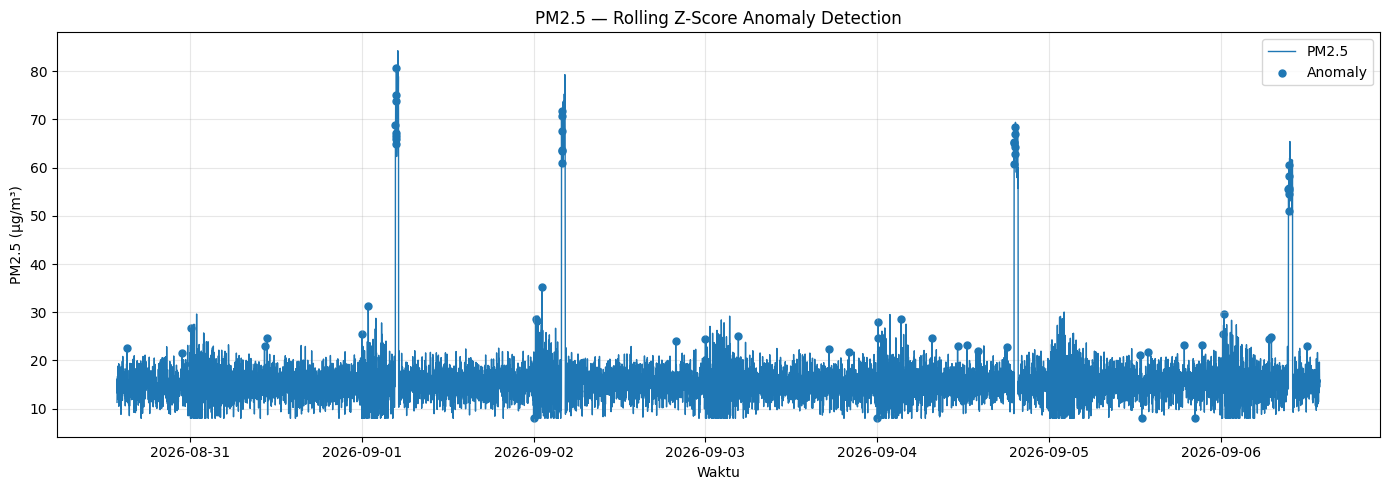

In [8]:
#Visualisasi PM2.5
pm25_anomaly = anomaly_df[
    anomaly_df["pm25_ugm3_anomaly_zscore"]
]

plt.figure(figsize=(14, 5))

plt.plot(
    anomaly_df["created_at"],
    anomaly_df["pm25_ugm3"],
    label="PM2.5",
    linewidth=1
)

plt.scatter(
    pm25_anomaly["created_at"],
    pm25_anomaly["pm25_ugm3"],
    label="Anomaly",
    s=25
)

plt.title(
    "PM2.5 — Rolling Z-Score Anomaly Detection"
)

plt.xlabel("Waktu")
plt.ylabel("PM2.5 (µg/m³)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Interpretasi Rolling Z-Score

Dengan window historis 60 menit dan threshold |Z| > 3, metode Rolling Z-Score mendeteksi anomali pada seluruh parameter polutan dengan proporsi yang berbeda.

PM2.5 memiliki 64 kandidat anomali atau sekitar 0,639% dari observasi valid. Visualisasi menunjukkan bahwa metode mampu mendeteksi beberapa lonjakan konsentrasi yang berbeda secara jelas dari pola historis sebelumnya. Salah satu kandidat anomali terbesar memiliki konsentrasi PM2.5 sebesar 65,27 µg/m³ dibandingkan rolling mean sekitar 15,27 µg/m³, sehingga menghasilkan Z-Score sekitar 18,47.

NO2 menghasilkan anomaly rate tertinggi, yaitu sekitar 3,363%. Hal ini perlu diinterpretasikan secara hati-hati karena distribusi NO2 pada dataset dummy didominasi nilai nol. Kondisi tersebut dapat menyebabkan perubahan kecil atau spike menghasilkan deviasi yang relatif besar terhadap pola historis.

Hasil Rolling Z-Score menunjukkan bahwa metode statistik ini cukup sensitif terhadap perubahan lokal dan dapat digunakan sebagai baseline anomaly detection. Namun, kandidat anomali tidak secara otomatis menunjukkan kondisi berbahaya dan perlu dipisahkan dari mekanisme alert.

## 3. Isolation Forest Anomaly Detection

Isolation Forest digunakan sebagai pendekatan machine learning untuk mendeteksi observasi yang berbeda dari pola multivariat data kualitas udara.

Berbeda dengan Rolling Z-Score yang mengevaluasi setiap parameter secara individual terhadap pola historis lokal, Isolation Forest dapat mempertimbangkan kombinasi beberapa parameter secara bersamaan.

Fitur yang digunakan meliputi konsentrasi PM2.5, PM10, CO, NO2, O3, temperature, dan humidity.

Pada tahap eksperimen ini, Isolation Forest digunakan sebagai metode pembanding. Hasil deteksi tidak langsung dianggap sebagai kondisi berbahaya atau alert.

In [9]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

iforest_features = [
    "pm25_ugm3",
    "pm10_ugm3",
    "co_ugm3",
    "no2_ugm3",
    "o3_ugm3",
    "temperature",
    "humidity"
]

X_iforest = anomaly_df[
    iforest_features
].copy()

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_iforest
)

print("Shape data:", X_scaled.shape)

Shape data: (10081, 7)


In [10]:
#Train Isolation Forest
iforest = IsolationForest(
    n_estimators=300,
    contamination=0.01,
    random_state=42,
    n_jobs=-1
)

iforest_prediction = iforest.fit_predict(
    X_scaled
)

anomaly_df["iforest_prediction"] = (
    iforest_prediction
)

anomaly_df["iforest_anomaly"] = (
    anomaly_df["iforest_prediction"] == -1
)

anomaly_df["iforest_score"] = (
    iforest.decision_function(
        X_scaled
    )
)

print(
    anomaly_df["iforest_anomaly"]
    .value_counts()
)

print(
    "\nAnomaly rate:",
    round(
        anomaly_df["iforest_anomaly"].mean()
        * 100,
        3
    ),
    "%"
)

iforest_anomaly
False    9980
True      101
Name: count, dtype: int64

Anomaly rate: 1.002 %


In [11]:
#Lihat observasi paling abnormal
iforest_top = (
    anomaly_df.loc[
        anomaly_df["iforest_anomaly"],
        [
            "created_at",
            *iforest_features,
            "iforest_score"
        ]
    ]
    .sort_values(
        "iforest_score"
    )
    .head(20)
)

iforest_top

,created_at,pm25_ugm3,pm10_ugm3,co_ugm3,no2_ugm3,o3_ugm3,temperature,humidity,iforest_score
2341,2026-09-01 04:50:00+00:00,80.600,91.550,2721.100,0.000,19.630,30.950,74.580,-0.068
3752,2026-09-02 04:21:00+00:00,74.460,83.390,2640.970,0.670,19.630,32.260,72.170,-0.057
9832,2026-09-06 09:41:00+00:00,61.380,68.080,3345.600,1.170,38.080,36.300,55.340,-0.052
2357,2026-09-01 05:06:00+00:00,76.630,83.400,2682.810,0.000,20.930,31.940,70.490,-0.050
2347,2026-09-01 04:56:00+00:00,74.430,80.600,2470.460,0.000,20.620,32.190,69.890,-0.048
2348,2026-09-01 04:57:00+00:00,78.700,85.730,2617.700,0.850,19.630,33.890,66.590,-0.048
3731,2026-09-02 04:00:00+00:00,71.700,78.590,2551.300,0.000,19.630,31.800,72.990,-0.048
9821,2026-09-06 09:30:00+00:00,60.430,62.310,3356.920,1.310,34.670,35.440,59.600,-0.046
2356,2026-09-01 05:05:00+00:00,73.040,85.120,2221.460,0.000,19.630,33.410,67.590,-0.045
2350,2026-09-01 04:59:00+00:00,78.510,85.520,2605.380,0.000,21.060,32.910,70.920,-0.043


Semakin negatif iforest_score, semakin kuat indikasi bahwa observasi tersebut berbeda dari pola data menurut model.

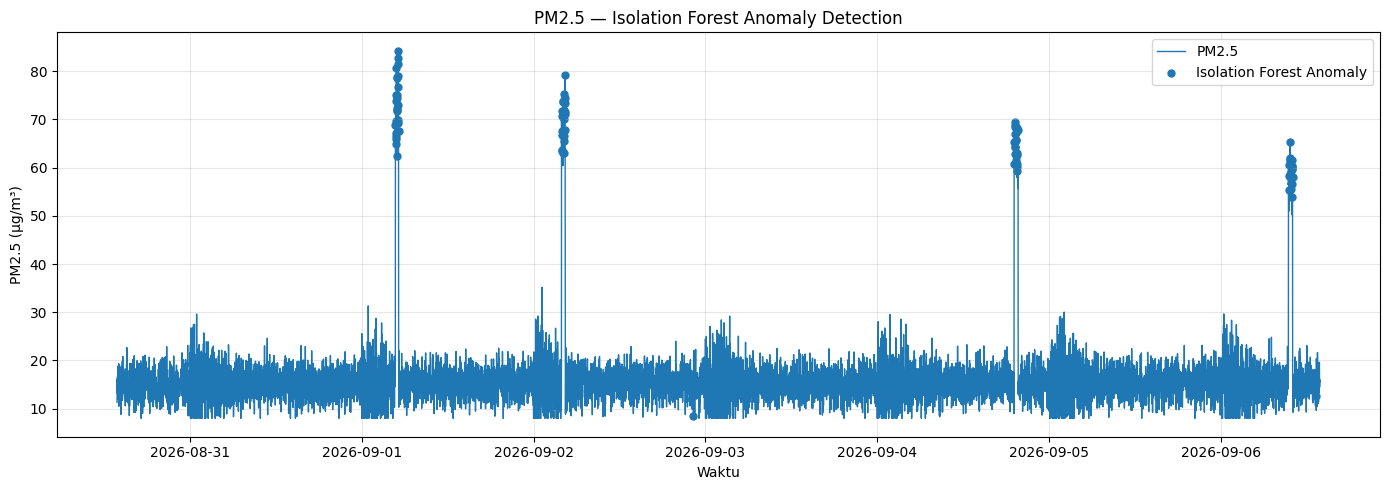

In [12]:
#Visualisasi Isolation Forest PM2.5
iforest_anomalies = anomaly_df[
    anomaly_df["iforest_anomaly"]
]

plt.figure(figsize=(14, 5))

plt.plot(
    anomaly_df["created_at"],
    anomaly_df["pm25_ugm3"],
    label="PM2.5",
    linewidth=1
)

plt.scatter(
    iforest_anomalies["created_at"],
    iforest_anomalies["pm25_ugm3"],
    label="Isolation Forest Anomaly",
    s=25
)

plt.title(
    "PM2.5 — Isolation Forest Anomaly Detection"
)

plt.xlabel("Waktu")
plt.ylabel("PM2.5 (µg/m³)")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

In [13]:
#Bandingkan Z-Score dan Isolation Forest
zscore_anomaly_cols = [
    f"{col}_anomaly_zscore"
    for col in pollutant_cols
]

anomaly_df["any_zscore_anomaly"] = (
    anomaly_df[
        zscore_anomaly_cols
    ]
    .any(axis=1)
)

In [14]:
comparison_anomaly = pd.crosstab(
    anomaly_df["any_zscore_anomaly"],
    anomaly_df["iforest_anomaly"],
    rownames=["Any Z-Score Anomaly"],
    colnames=["Isolation Forest Anomaly"]
)

comparison_anomaly

Isolation Forest Anomaly,False,True
Any Z-Score Anomaly,,
False,9405,71
True,575,30


In [15]:
both = (
    anomaly_df["any_zscore_anomaly"]
    & anomaly_df["iforest_anomaly"]
).sum()

zscore_only = (
    anomaly_df["any_zscore_anomaly"]
    & ~anomaly_df["iforest_anomaly"]
).sum()

iforest_only = (
    ~anomaly_df["any_zscore_anomaly"]
    & anomaly_df["iforest_anomaly"]
).sum()

neither = (
    ~anomaly_df["any_zscore_anomaly"]
    & ~anomaly_df["iforest_anomaly"]
).sum()

method_comparison = pd.DataFrame({
    "Condition": [
        "Detected by both",
        "Z-Score only",
        "Isolation Forest only",
        "Neither"
    ],
    "Count": [
        both,
        zscore_only,
        iforest_only,
        neither
    ]
})

method_comparison

,Condition,Count
0,Detected by both,30
1,Z-Score only,575
2,Isolation Forest only,71
3,Neither,9405


### Interpretasi Isolation Forest

Isolation Forest dengan contamination 1% menandai 101 dari 10.081 observasi sebagai kandidat anomali. Jumlah tersebut dipengaruhi oleh nilai contamination yang ditetapkan pada eksperimen sehingga tidak dapat diinterpretasikan sebagai estimasi bahwa secara alami tepat 1% data merupakan anomali.

Observasi dengan anomaly score terendah menunjukkan kombinasi nilai yang berbeda dari pola mayoritas data. Beberapa di antaranya bertepatan dengan periode lonjakan PM2.5 dan PM10 yang terlihat jelas pada visualisasi.

Perbandingan dengan Rolling Z-Score menunjukkan bahwa hanya 30 observasi terdeteksi oleh kedua metode. Sebanyak 575 observasi hanya terdeteksi Rolling Z-Score, sedangkan 71 observasi hanya terdeteksi Isolation Forest.

Perbedaan tersebut terjadi karena kedua metode memiliki perspektif yang berbeda. Rolling Z-Score mendeteksi perubahan lokal masing-masing polutan terhadap riwayat sebelumnya, sedangkan Isolation Forest mengevaluasi ketidakbiasaan kombinasi beberapa variabel secara multivariat.

Karena dataset tidak memiliki ground-truth label anomali, hasil ini tidak digunakan untuk menghitung accuracy, precision, recall, atau menentukan salah satu metode sebagai model terbaik.

In [16]:
#Kombinasi Anomaly per Polutan
anomaly_pattern = pd.DataFrame({
    "Parameter": pollutant_cols,
    "Anomaly_Count": [
        anomaly_df[
            f"{col}_anomaly_zscore"
        ].sum()
        for col in pollutant_cols
    ]
})

anomaly_pattern["Percentage_of_Data"] = (
    anomaly_pattern["Anomaly_Count"]
    / len(anomaly_df)
    * 100
)

anomaly_pattern[
    "Percentage_of_Data"
] = anomaly_pattern[
    "Percentage_of_Data"
].round(3)

anomaly_pattern

,Parameter,Anomaly_Count,Percentage_of_Data
0,pm25_ugm3,64,0.635
1,pm10_ugm3,63,0.625
2,co_ugm3,85,0.843
3,no2_ugm3,337,3.343
4,o3_ugm3,103,1.022


In [17]:
#Cek Berapa polutan yang anomalous secara bersamaan pada setiap timestamp
anomaly_df["zscore_anomaly_count"] = (
    anomaly_df[
        zscore_anomaly_cols
    ]
    .sum(axis=1)
)

anomaly_df[
    "zscore_anomaly_count"
].value_counts().sort_index()

zscore_anomaly_count
0    9476
1     560
2      43
3       2
Name: count, dtype: int64

In [18]:
#Anomaly Evidence
anomaly_df["anomaly_evidence"] = "None"

anomaly_df.loc[
    anomaly_df["any_zscore_anomaly"],
    "anomaly_evidence"
] = "Z-Score"

anomaly_df.loc[
    anomaly_df["iforest_anomaly"],
    "anomaly_evidence"
] = "Isolation Forest"

anomaly_df.loc[
    (
        anomaly_df["any_zscore_anomaly"]
        & anomaly_df["iforest_anomaly"]
    ),
    "anomaly_evidence"
] = "Both"

anomaly_df[
    "anomaly_evidence"
].value_counts()

anomaly_evidence
None                9405
Z-Score              575
Isolation Forest      71
Both                  30
Name: count, dtype: int64

## 4. Kesimpulan Anomaly Detection

Eksperimen anomaly detection dilakukan menggunakan dua pendekatan, yaitu Rolling Z-Score sebagai metode statistik berbasis pola historis lokal dan Isolation Forest sebagai metode multivariat.

Rolling Z-Score mampu mengidentifikasi perubahan konsentrasi yang berbeda dari pola 60 menit sebelumnya pada masing-masing parameter. Isolation Forest memberikan perspektif tambahan dengan mendeteksi kombinasi kondisi antarvariabel yang tidak biasa.

Kedua metode tidak menghasilkan kandidat anomali yang identik karena menggunakan definisi ketidakbiasaan yang berbeda. Oleh karena itu, hasil keduanya dipertahankan sebagai anomaly evidence dan tidak langsung dikonversi menjadi alert.

Anomali juga tidak diartikan sebagai kondisi berbahaya. Mekanisme alert AirSense akan mempertimbangkan informasi kualitas udara berbasis regulasi, anomaly evidence, dan hasil forecasting secara terpisah.

Karena eksperimen masih menggunakan data dummy dan tidak tersedia ground-truth label anomali, konfigurasi window, threshold, dan contamination perlu dievaluasi kembali ketika data riil IoT tersedia.

In [19]:
#Simpan Hasil Anomaly Detection
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Ringkasan anomaly per parameter
anomaly_pattern.to_csv(
    OUTPUT_DIR / "anomaly_zscore_summary.csv",
    index=False
)

# Hasil lengkap anomaly detection
anomaly_output_cols = [
    "created_at",
    *pollutant_cols,
    "any_zscore_anomaly",
    "zscore_anomaly_count",
    "iforest_anomaly",
    "iforest_score",
    "anomaly_evidence"
]

anomaly_df[
    anomaly_output_cols
].to_csv(
    OUTPUT_DIR / "anomaly_detection_results.csv",
    index=False
)

print(
    "Hasil anomaly detection berhasil disimpan."
)

Hasil anomaly detection berhasil disimpan.
